# The transcriptional and regulatory identity of erythropoietin producing cells (single-cell RNA-seq data - mouse)

Method: MARS seq (Massively Arrayed RNA Single-cell sequencing), a well-based single-cell RNA-seq protocol where each cell is sorted into a separate well, barcoded, and sequenced in bulk. Not a 10x Genomics. <br>
Note: original paper used Seurat <br>
NovaSeq 6000 instrument <br>
Authors used MetaCell package for scRNA-seq analysis to group normoxic and hypoxic cells

**Citation**: Kragesteen BK et all The transcriptional and regulatory identity of erythropoietin producing cells. Nat Med. 2023 May;29(5):1191-1200

**Goals of the analysis:** 
- obtaining data from GEO NCBI; 
- practicing working with an expression matrix, adata, and main functions in Scanpy; 
- preprocessing and quality control (QC);
- visualizing the data <br>
Note: Assigning cell populations is beyond the scope of this analysis, as it was performed in the paper by experts in kidney structure and biology.

In [2]:
import os
import pandas as pd
import scanpy as sc
from urllib.request import urlretrieve

### Load dataset

In [4]:
data_folder_name = "data_Epo_cells_Norn"

In [3]:
!mkdir data_Epo_cells_Norn

Of course you can use wget on Linux, code below should work on all OS.

In [4]:
base_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE193nnn/GSE193321/suppl/"

files = [
    "GSE193321_matrix.mtx.gz",
    "GSE193321_features.tsv.gz",
    "GSE193321_barcodes.tsv.gz",
    "GSE193321_metadata_f.txt.gz"
]

for file in files:
    url = base_url + file
    output_path = os.path.join(data_folder_name, file)
    
    print(f"Downloading {file}...")
    urlretrieve(url, output_path)

print("Done")

Done


In [5]:
results_file = 'Epo_cells_Norn.h5ad'

In [6]:
# rename files to match how data reading function expects them
os.rename(os.path.join(data_folder_name, "GSE193321_matrix.mtx.gz"),
          os.path.join(data_folder_name, "matrix.mtx.gz"))

os.rename(os.path.join(data_folder_name, "GSE193321_features.tsv.gz"),
          os.path.join(data_folder_name, "features.tsv.gz"))

os.rename(os.path.join(data_folder_name, "GSE193321_barcodes.tsv.gz"),
          os.path.join(data_folder_name, "barcodes.tsv.gz"))

os.rename(os.path.join(data_folder_name, "GSE193321_metadata_f.txt.gz"),
          os.path.join(data_folder_name, "metadata_f.txt.gz"))

### Make adata object from the data

In [6]:
adata = sc.read_10x_mtx(
    data_folder_name,
    var_names='gene_symbols',
    cache=True
)

adata

AnnData object with n_obs × n_vars = 3306 × 27998
    var: 'gene_ids', 'feature_types'

Adata.X contains sparse matrix for 3306 cells (their indexes) and 27998 genes expression levels in these cells

In [76]:
adata.to_df().head()

,Xkr4,Rp1,Sox17,Mrpl15,Rgs20,Sntg1,1700034P13Rik,Prex2,Sulf1,Eya1,...,Cfap43,Sorcs3,Sorcs1,Gm16299,Afap1l2,B230217O12Rik,Shtn1,Grk5,Csprs,PISD
AAACAGCCAACAGCCT-1,-0.128920,-0.200014,0.025013,-0.166232,-0.051091,0.001808,0.011310,0.083220,-0.159233,-0.036981,...,0.010317,-0.024268,0.018865,0.046535,-0.295360,0.005765,-0.118410,-0.185733,0.029564,-0.397327
AAACAGCCAAGGTCGA-1,-0.140959,-0.028160,-0.250544,-0.227510,-0.066915,-0.098724,-0.073226,-0.586344,-0.237749,-0.155530,...,-0.596405,-0.180525,-0.106882,-0.076717,-0.244349,-0.105211,-0.094263,-0.402174,-0.070562,-0.381367
AAACAGCCAGGCTAGA-1,-0.110749,-0.112113,-0.151867,-0.134853,-0.055628,-0.007987,-0.023841,-0.302638,-0.179538,-0.059762,...,-0.379528,-0.037345,-0.021726,0.000985,-0.297449,-0.040656,-0.044918,-0.301473,-0.030660,-0.375346
AAACGCGCAAATTCGT-1,-0.199451,-0.077535,-0.079867,-0.369618,-0.071424,-0.175835,-0.069532,-0.283498,-0.265747,-0.217862,...,-0.219617,2.735090,-0.131171,-0.085845,-0.187247,6.361901,5.635460,-0.327170,-0.018848,-0.421138
AAACGCGCATGTCAAT-1,-0.145939,-0.062767,-0.184116,-0.234259,-0.064811,-0.091148,-0.058664,-0.438306,-0.227980,-0.143177,...,-0.450027,-0.169401,-0.088780,-0.057220,-0.246045,-0.086011,-0.117733,-0.357056,-0.047656,2.245664


Cell indexes are stored in adata.obs and genes with their Ensembl genome database IDs are stored in adata.var

In [9]:
adata.obs.head() # cell indexes

""
AAACAGCCAACAGCCT-1
AAACAGCCAAGGTCGA-1
AAACAGCCAGGCTAGA-1
AAACGCGCAAATTCGT-1
AAACGCGCATGTCAAT-1


In [7]:
adata.var.head() # gene names and ids, these ones are mouse

,gene_ids,feature_types
Xkr4,ENSMUSG00000051951,Gene Expression
Gm1992,ENSMUSG00000089699,Gene Expression
Gm37381,ENSMUSG00000102343,Gene Expression
Rp1,ENSMUSG00000025900,Gene Expression
Rp1-1,ENSMUSG00000109048,Gene Expression


### Add metadata

In [23]:
metadata = pd.read_csv(
    f"{data_folder_name}/metadata_f.txt.gz",
    sep="\t"
)

In [24]:
metadata.head()

,Unnamed: 0,amp_batch_id,seq_batch_id,well_coordinates,Cell_barcode,Pool_barcode,Pool_barcode_i5,Number_of_cells,metacell,group,color,genetics,treatment,sc_x_fig.2,sc_y_fig.2
0,WMC2170529,AB9040,SB387,A1,CTATTCG,TATACGGC,GTATCTCG,1,122.0,Proximal tubule,gray30,B6,hypoxia (4h CO),860.66,1532.52
1,WMC2170530,AB9040,SB387,C1,ACTCAGG,TATACGGC,GTATCTCG,1,NaN,NaN,NaN,B6,hypoxia (4h CO),NaN,NaN
2,WMC2170531,AB9040,SB387,E1,ACACGTG,TATACGGC,GTATCTCG,1,NaN,NaN,NaN,B6,hypoxia (4h CO),NaN,NaN
3,WMC2170532,AB9040,SB387,G1,TCTTCGA,TATACGGC,GTATCTCG,1,NaN,NaN,NaN,B6,hypoxia (4h CO),NaN,NaN
4,WMC2170533,AB9040,SB387,I1,AGCACTG,TATACGGC,GTATCTCG,1,NaN,NaN,NaN,B6,hypoxia (4h CO),NaN,NaN


In [25]:
metadata.columns

Index(['Unnamed: 0', 'amp_batch_id', 'seq_batch_id', 'well_coordinates',
       'Cell_barcode', 'Pool_barcode', 'Pool_barcode_i5', 'Number_of_cells',
       'metacell', 'group', 'color', 'genetics', 'treatment', 'sc_x_fig.2',
       'sc_y_fig.2'],
      dtype='object')

In [26]:
metadata["treatment"].unique() # There are hypoxic and normoxic cell

array(['hypoxia (4h CO)', 'normoxia'], dtype=object)

In [27]:
metadata["genetics"].unique() 

# “B6” is C57BL/6 or simply a wild-type (non-modified) mouse. 
# "tdTomato-EPO B6" is a C57BL/6 mouse engineered so that EPO-expressing cells are tagged with red fluorescence (tdTomato)

array(['B6', 'tdTomato-EPO B6'], dtype=object)

In [28]:
metadata["group"].unique() # Cell types

array(['Proximal tubule', nan, 'Proximal tubule2', 'Pericyte3',
       'Monocytes', 'Fibroblasts', 'Pericyte1', 'Norn', 'Collecting duct',
       'Collecting duct transient', 'Macrophages', 'Pericyte Ren1+',
       'T lymphocyte', 'Loop of henle', 'Distal convoluted tubule',
       'Other', 'Collecting duct intercalated', 'Endothelial',
       'Pericyte2', 'Collecting duct principal', 'Podocytes',
       'Neutrophil'], dtype=object)

In [29]:
len(metadata["metacell"].unique()) # There are these many metacells (385 actually as it counts NA too)

386

 Let's add this information to the adata

In [30]:
# These are cell barcodes in the adata table. However in the metadata there is no single colum that would exactly match
# The full 10x cell barcodes are ~16 bp + suffix
# i5 and i7 are each 8bp long sample identity barcodes, they do NOT create the cell barcode

adata.obs_names

Index(['AAACAGCCAACAGCCT-1', 'AAACAGCCAAGGTCGA-1', 'AAACAGCCAGGCTAGA-1',
       'AAACGCGCAAATTCGT-1', 'AAACGCGCATGTCAAT-1', 'AAACGTACAACTCGCG-1',
       'AAACGTACAAGTTATC-1', 'AAAGCAAGTCAACAAT-1', 'AAAGCAAGTTAAGTGT-1',
       'AAAGCAAGTTGGTTCT-1',
       ...
       'TTTGTCCCATAAGCAA-1', 'TTTGTCTAGCGAGCGA-1', 'TTTGTCTAGGCGCACT-1',
       'TTTGTGGCACAATGCC-1', 'TTTGTGGCAGCAAGGC-1', 'TTTGTGGCATAGCGAG-1',
       'TTTGTGGCATCCAGGT-1', 'TTTGTGTTCAATGTGC-1', 'TTTGTGTTCGCTAGAT-1',
       'TTTGTTGGTAGCCATA-1'],
      dtype='object', length=3306)

In [31]:
metadata["Cell_barcode"] # Cell_barcode here is 7bp not 16bp. It was somehow modified during data processing

# Seems like it is because authors used metacell clustering. So now it is not a cell barcode, it is a label for a cluster of cells
# It is not possible to match metadata file directly to the matrix

0        CTATTCG
1        ACTCAGG
2        ACACGTG
3        TCTTCGA
4        AGCACTG
          ...   
57211    GGACATT
57212    ATTCAGC
57213    ATTCGCG
57214    TGAAGCT
57215    CACGTAT
Name: Cell_barcode, Length: 57216, dtype: object

In [32]:
len(metadata["Cell_barcode"].unique())

1152

In [33]:
# GEO also has RAW file for this paper. Let's see one of the files (there are many files sample by sample)
df_example = pd.read_csv("data_Epo_cells_Norn/GSM5792047_AB9040.txt.gz", sep="\t")

In [77]:
df_example .head()
# contains 3gene × cell count matrix (UMI counts)
# rows - gene names
# columns seem to be wells - from paper: Single cells were sorted into 384-well cell capture plates, 4 wells were kept empty
# these are per-sample files
# Unfortunately they can not help with the assignment of the metadata

,WMC2170529,WMC2170530,WMC2170531,WMC2170532,WMC2170533,WMC2170534,WMC2170535,WMC2170536,WMC2170537,WMC2170538,...,WMC2170903,WMC2170904,WMC2170905,WMC2170906,WMC2170907,WMC2170908,WMC2170909,WMC2170910,WMC2170911,WMC2170912
0610005C13Rik,0,0,0,0,1,0,1,0,2,0,...,1,0,3,0,1,0,0,0,2,4
0610006L08Rik,0,0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0610009B22Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
0610009E02Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0610009L18Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Without metadata my options for analysis are limited, but I will try to do QC and identify which cells cluster together.

### Preprocessing and QC

See what the highest expression genes

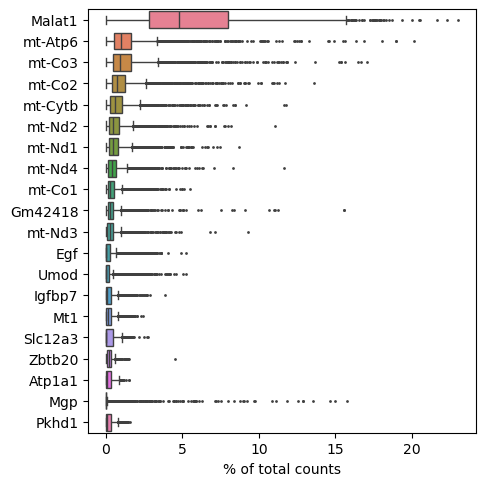

AnnData object with n_obs × n_vars = 3306 × 27998
    var: 'gene_ids', 'feature_types'

In [35]:
sc.pl.highest_expr_genes(adata, n_top=20, )
adata

Let's filter out cells with too little genes detected (dead cells or empty droplets) and genes that were detected in too little cells (probably noise). 

**From the paper**:
For 10x Genomics scRNA-seq, suspected doublets and cells with fewer than 200 unique molecular identifiers (UMIs) and more than 25% mitochondrial content were excluded: nFeature_RNA > 200 & nFeature_RNA < 5000 & percent.mt <25.

In [36]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3) # This is not a filter used by original paper but it is standard and makes sence
# Added columns: 
    #'n_genes' - how many genes are expressed in that cell 
    #'n_cells' - for how many cells particular gene is expressed 
    
adata

AnnData object with n_obs × n_vars = 3272 × 16953
    obs: 'n_genes'
    var: 'gene_ids', 'feature_types', 'n_cells'

Now there are new columns in obs and var.

In [37]:
adata.obs.head()

,n_genes
AAACAGCCAACAGCCT-1,425
AAACAGCCAAGGTCGA-1,1169
AAACAGCCAGGCTAGA-1,207
AAACGCGCAAATTCGT-1,2260
AAACGCGCATGTCAAT-1,1116


In [38]:
adata.var.head()

,gene_ids,feature_types,n_cells
Xkr4,ENSMUSG00000051951,Gene Expression,78
Rp1,ENSMUSG00000025900,Gene Expression,18
Sox17,ENSMUSG00000025902,Gene Expression,114
Mrpl15,ENSMUSG00000033845,Gene Expression,211
Lypla1,ENSMUSG00000025903,Gene Expression,279


Quality control (high proportion of mitochondrial cells -> stressed/dying cells)

Add column with boolean values to find which genes are mitochondrial <br>
pp = preprocessing module <br>

Let's calculate percentage of counts coming from mitochondrial genes for each cell

In [39]:
adata.var['mt'] = adata.var_names.str.startswith('mt-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
# Added columns: 
    # for obs - 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    # for var -  'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
adata

AnnData object with n_obs × n_vars = 3272 × 16953
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

Let's visualize:

* n_genes_by_counts - number of genes detected in a cell (we already removed values under 200, whatever is an outlier high - probably doublet of cells). 
* total_counts - total RNA counts in a cell (too low - > poor quality, too high -> also doublets or highly metabolically active cells)
* pct_counts_mt - percentage of RNA coming from mitochondrial genes (5% - normal, 5-10% borderline, >10% stressed/dying)

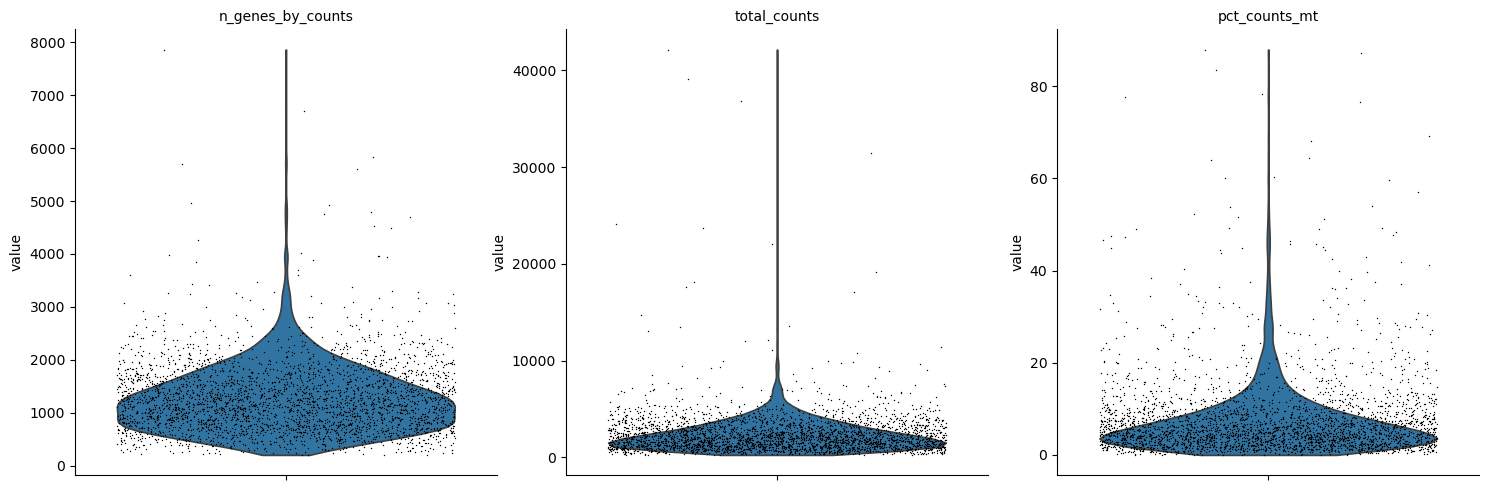

In [40]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

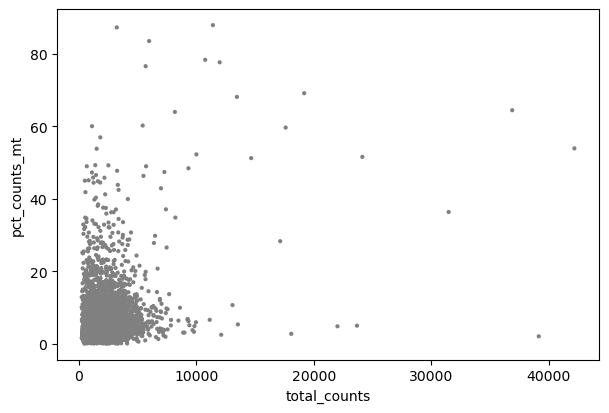

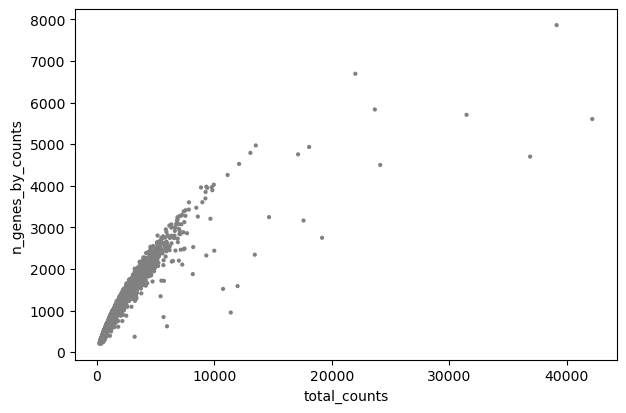

In [41]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt') 
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')
# Interpretation:

# 🔴 High MT + low genes → likely bad cells
# 🟢 High MT + high genes → possibly real biology

Now we filter out cells where:
- under 25% (from paper)
- total genes detected under 5000 (from paper, to exclude doublets)

Removed 221 cells. These could be potential doublets. For total gene number is it possible to use tools such as <b> Scrublet (Python) and DoubletFinder (R).  
    
Let's replot.

In [42]:
adata = adata[adata.obs.n_genes_by_counts < 5000, :]

adata = adata[adata.obs["pct_counts_mt"] < 25, :]

adata

View of AnnData object with n_obs × n_vars = 3148 × 16953
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

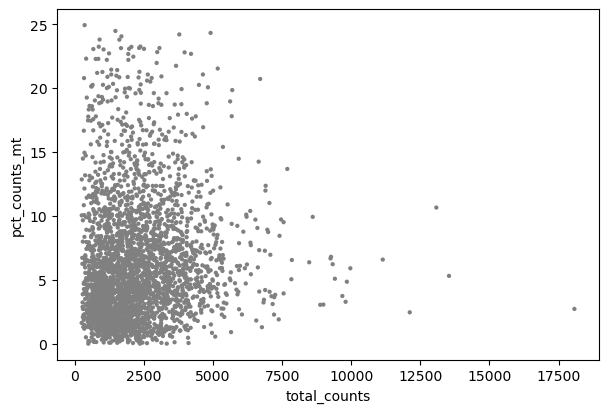

In [43]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt') 

Library-size normalization (counts for each cell are normalized in a way so that if it had 10,000 reads per cell). Makes counts  comparable among cells (before that some cells are deeper or shallower sequenced). 

Formula: 
normalized counts = original counts/total counts in the cell X 10,000

In [44]:
sc.pp.normalize_total(adata, target_sum=1e4)

C:\Users\volko\anaconda3\lib\site-packages\scanpy\preprocessing\_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Logarithmize the data to prevent the downstream analysis being dominated by genes with very high counts and of course to avoid log(0):

log(1 + normalized counts)

In [45]:
sc.pp.log1p(adata)

### Identify highly-variable genes

These genes are actually distinguishing cell types.

This will calculate mean expression and cut off genes that are barely expressed anywhere and genes that are expressed everywhere. And it keeps genes with expression varying more then expected.

Columns:
* highly_variable - Boolean mask: which genes are selected
* means, dispersions, dispersions_norm

In [46]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata

AnnData object with n_obs × n_vars = 3148 × 16953
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [47]:
adata.var[ [ 'highly_variable', 'means', 'dispersions', 'dispersions_norm' ]].head()

,highly_variable,means,dispersions,dispersions_norm
Xkr4,True,0.171115,2.650175,1.817221
Rp1,True,0.028572,2.555916,1.570271
Sox17,True,0.362313,2.998727,3.115410
Mrpl15,True,0.273283,2.278966,0.844689
Lypla1,False,0.326531,1.897451,-0.783162


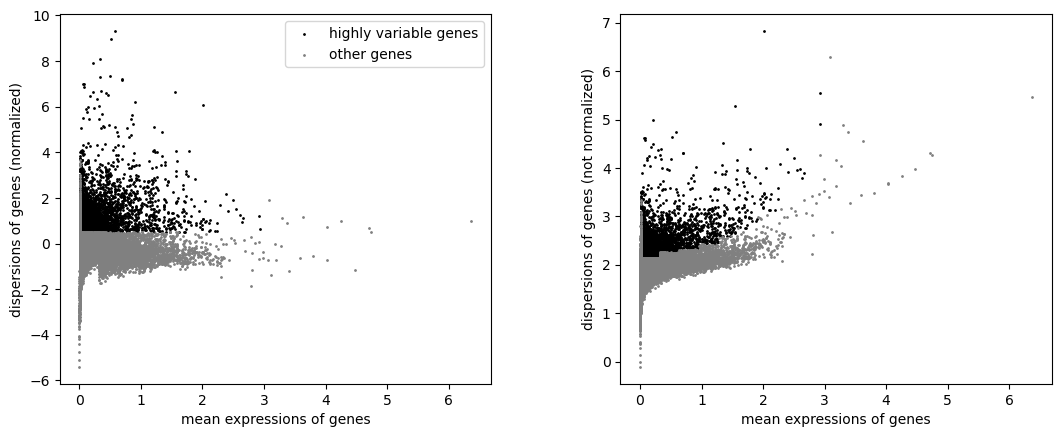

In [48]:
sc.pl.highly_variable_genes(adata)

Befor selecting only higly variable genes and scaling the data, we freez current state of dataset in .raw

In [49]:
adata.raw = adata

Now we keep in adata only highly variable genes.

In [50]:
adata = adata[:, adata.var.highly_variable]
adata

View of AnnData object with n_obs × n_vars = 3148 × 3784
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

Regress out will help to substrct the noise component from the data and see biological difference more clear. However, be aware that sometimes regressing out could be harmful as it can remove real biology - for instance activated or larger cells often have more RNA, or if you are looking for cells under stress they may actually have higher mitochondrial RNA for a reason, when doing differential expression you need log-normalized data.

Values substitutes with residuals (what is left after you remove variance explaind by sequencing depth and mt content).

In [51]:
not_regressed_data = adata.copy()

In [52]:
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

C:\Users\volko\anaconda3\lib\site-packages\scanpy\preprocessing\_simple.py:668: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Now we do z-score scaling per gene (mean - 0, standard deviation - 1), also any values higher then 10 or lower then -10 are substituted for 10 and -10.

In [53]:
sc.pp.scale(adata, max_value=10)

In [54]:
sc.pp.scale(not_regressed_data, max_value=10)

## PCA

In [55]:
sc.tl.pca(adata, svd_solver='arpack')

# Adds: adata.obsm.X_pca, adata.varm.PCs

In [56]:
sc.tl.pca(not_regressed_data, svd_solver='arpack')

In [57]:
adata

AnnData object with n_obs × n_vars = 3148 × 3784
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

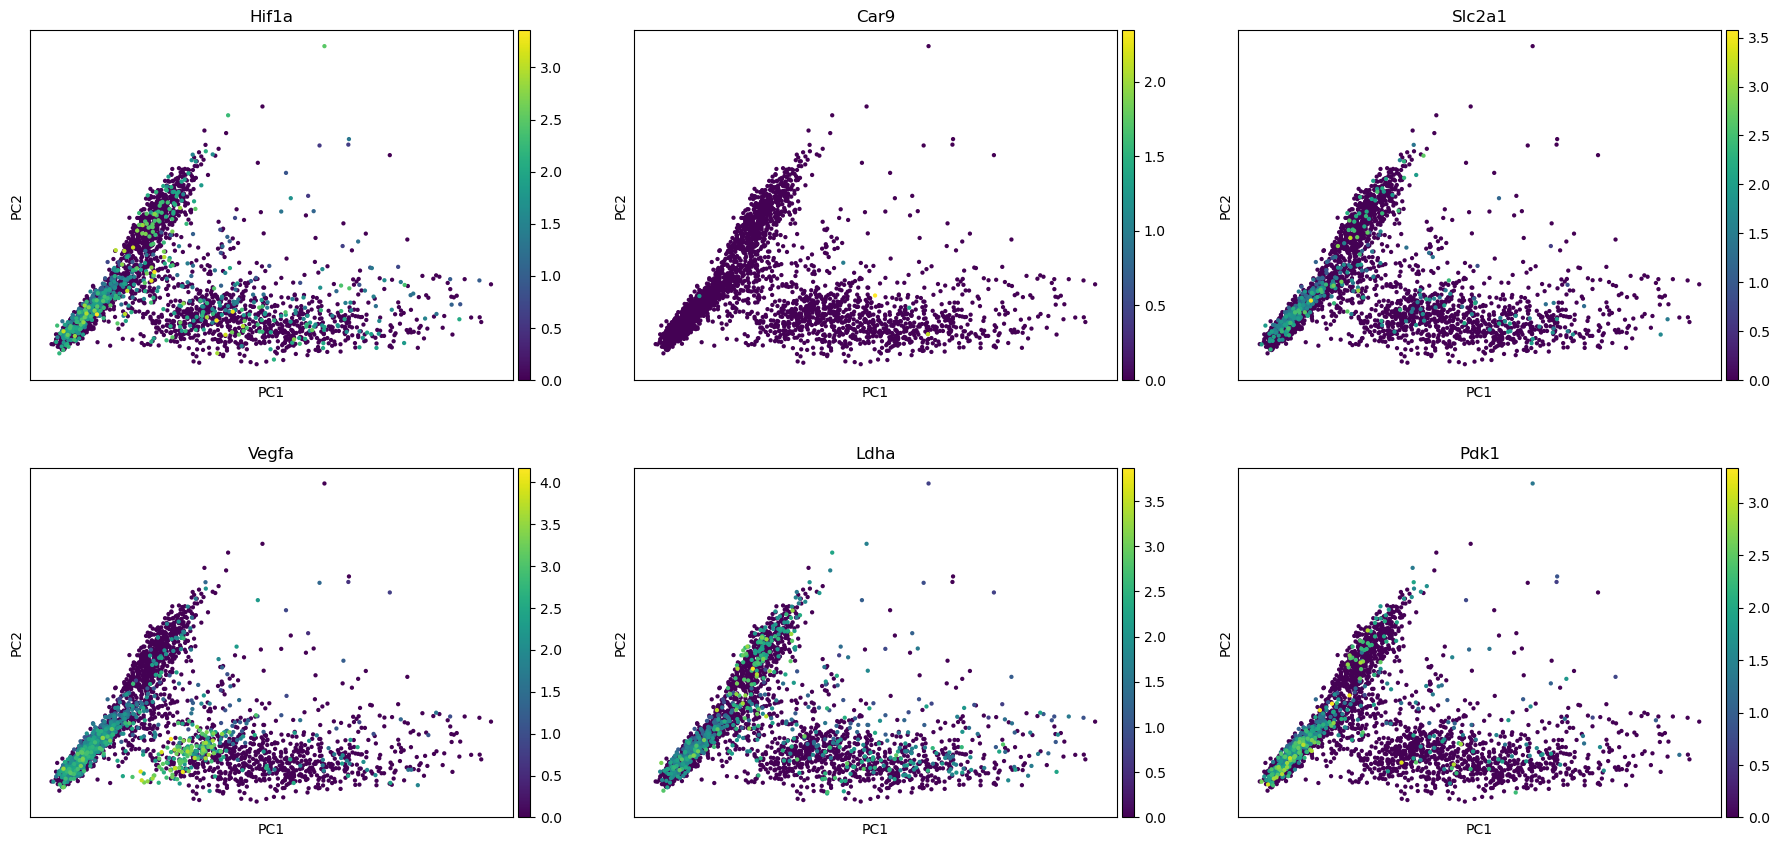

In [59]:
sc.pl.pca(
    adata,
    color=["Hif1a", "Car9", "Slc2a1", "Vegfa", "Ldha", "Pdk1"],
    ncols=3
)
# use hypoxia markers CA9, SLC2A1 (GLUT1), VEGFA, LDHA, PDK1 as HIF1A is not good marker of hypoxia itself
# for mouse: Car9, Slc2a1, Vegfa, Ldha, Pdk1

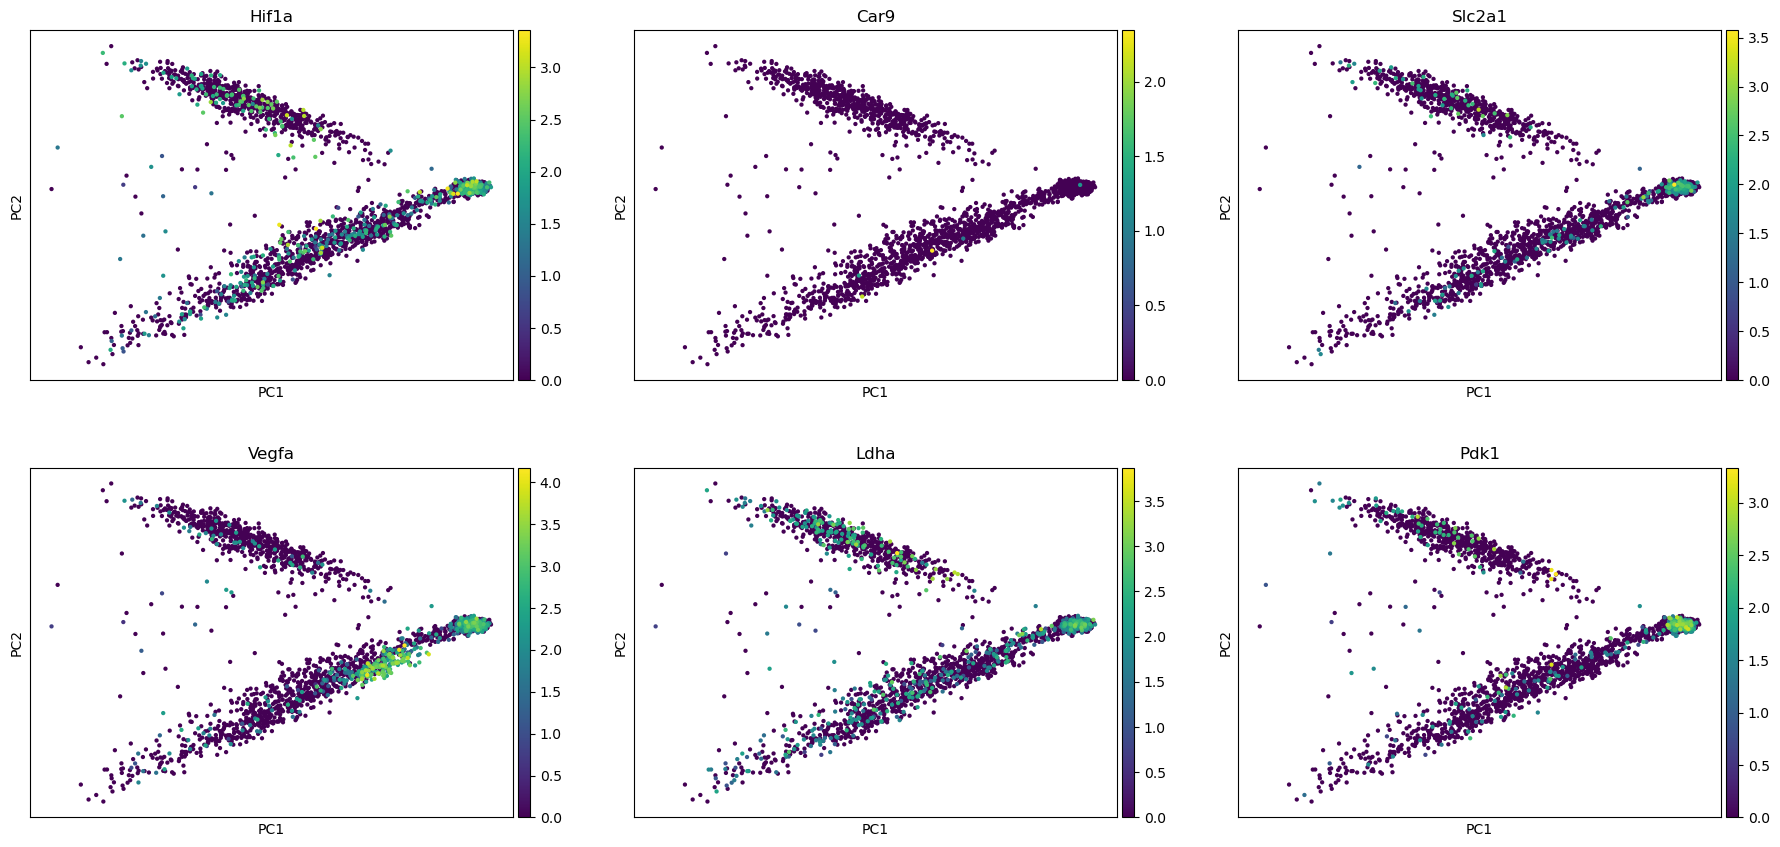

In [60]:
sc.pl.pca(
    not_regressed_data,
    color=["Hif1a", "Car9", "Slc2a1", "Vegfa", "Ldha", "Pdk1"],
    ncols=3
)

In both regressed and not repgressed data graphs we can see cells clustering to hypoxic and non hypoxic.

Let's see how many principal components are contributing the most and choose how many of them to use for following analysis.

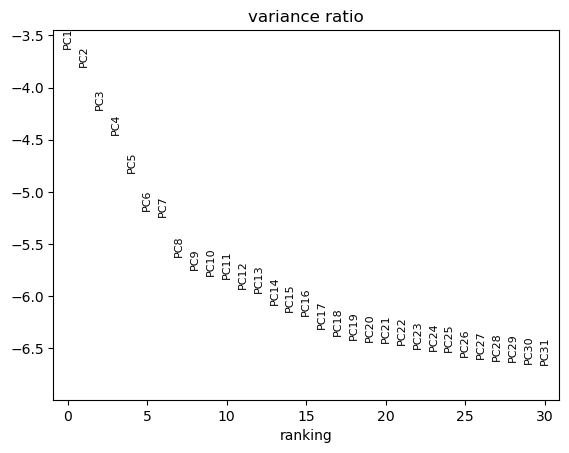

In [61]:
sc.pl.pca_variance_ratio(adata, log=True)

Save the result.

In [63]:
adata.write(results_file)

## Computing the neighborhood graph

Let us compute the neighborhood graph of cells using the PCA representation of the data matrix. You might simply use default values here. For the sake of reproducing Seurat’s results, let’s take the following values.

In [64]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

In [65]:
sc.pp.neighbors(not_regressed_data, n_neighbors=10, n_pcs=40)

## Embedding the neighborhood graph

Embedding in that case is putting it into 2D.

Note - UMAP embedding:
- is not the raw data
- is not quantitative distance
- It’s a visual representation

We suggest embedding the graph in two dimensions using UMAP (McInnes et al., 2018), see below. It is potentially more faithful to the global connectivity of the manifold than tSNE, i.e., it better preserves trajectories. In some ocassions, you might still observe disconnected clusters and similar connectivity violations. They can usually be remedied by running:

sc.tl.paga(adata) sc.pl.paga(adata, plot=False) # remove plot=False if you want to see the coarse-grained graph sc.tl.umap(adata, init_pos='paga')

In [66]:
sc.tl.umap(adata)

In [67]:
sc.tl.umap(not_regressed_data)

In the paper it is important to show new kidney cell population Norn cells and fibroblasts and pericites. <br>
Let's see main markers for Norn cells: Cxcl14, Col1a1, Dcn, Lpar1

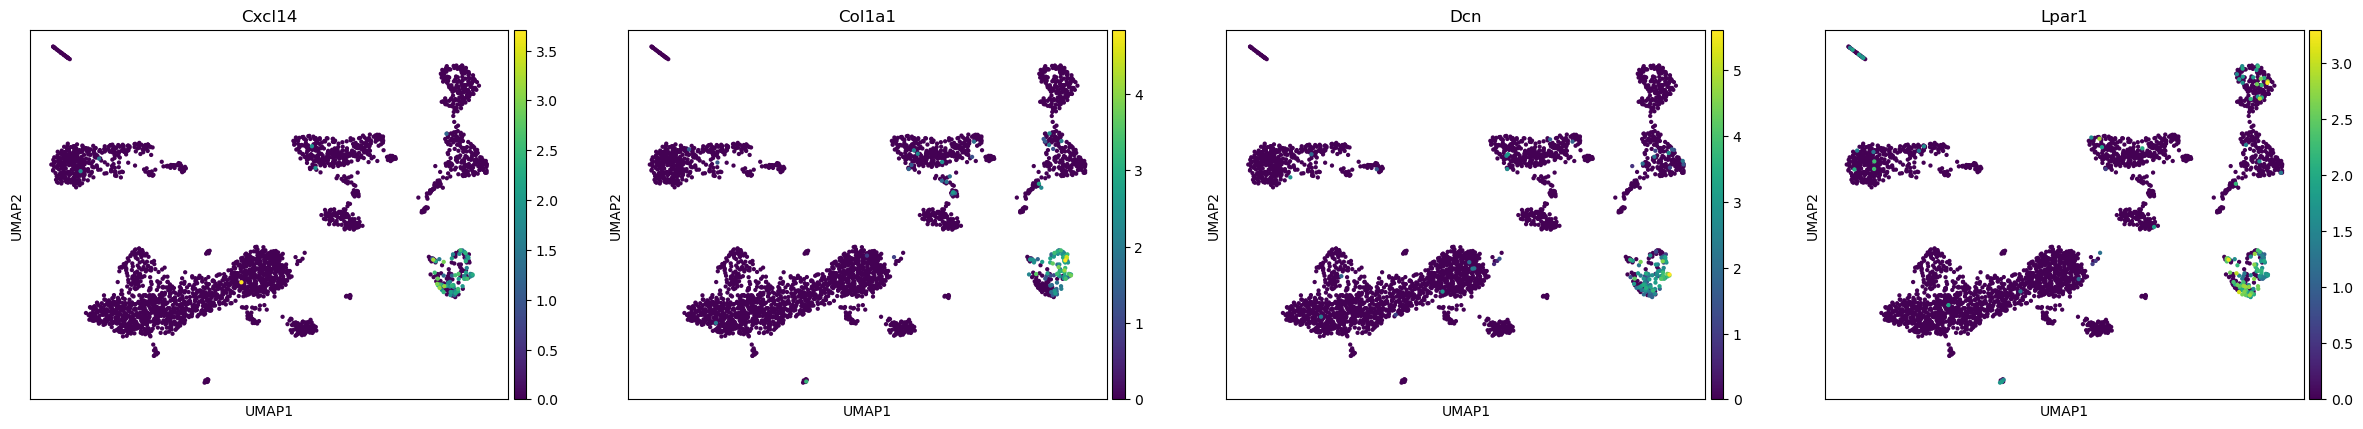

In [69]:
sc.pl.umap(adata, color=["Cxcl14", "Col1a1", "Dcn", "Lpar1"]) # regressed data

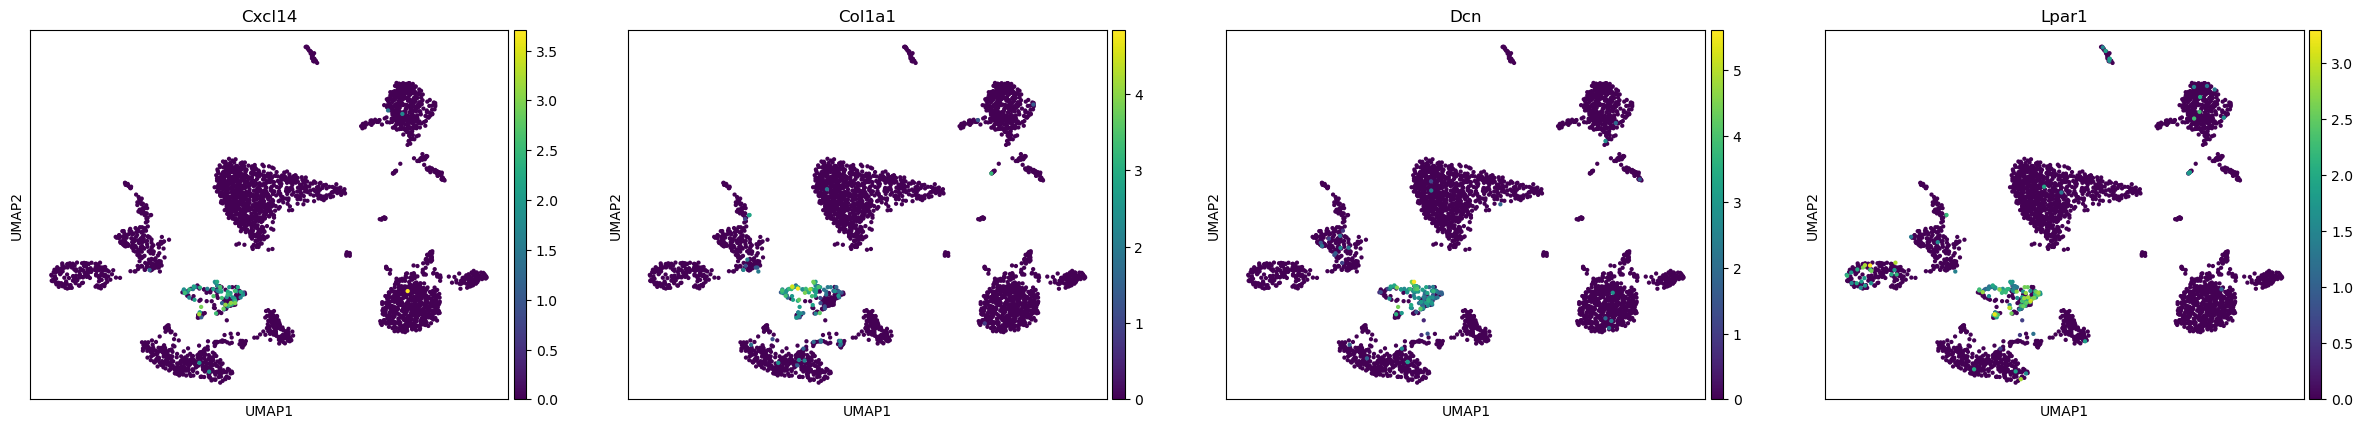

In [70]:
sc.pl.umap(not_regressed_data, color=["Cxcl14", "Col1a1", "Dcn", "Lpar1"]) # non-regressed data

Let's see fibroblasts and pericytes markers: Pdgfra, Pdgfrb, Rgs5 and Nt5e.

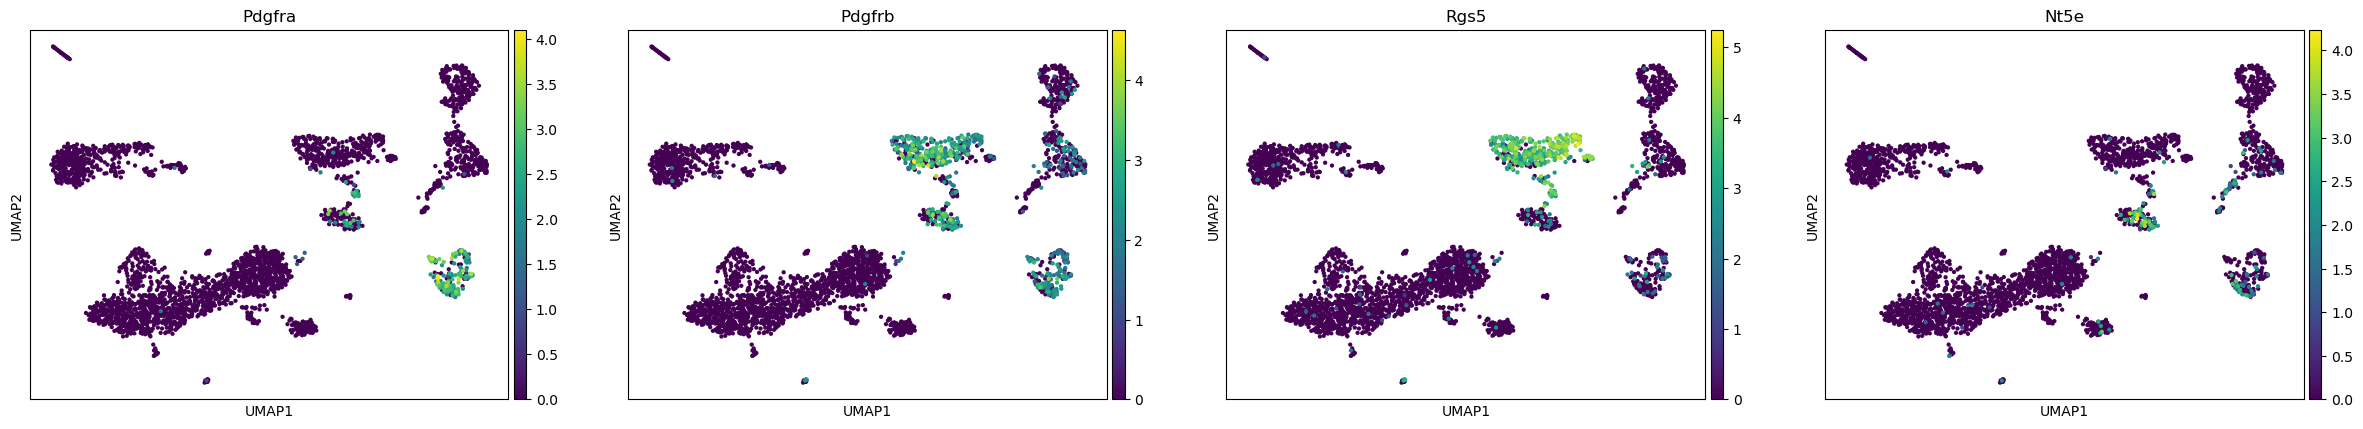

In [71]:
sc.pl.umap(adata, color=["Pdgfra", "Pdgfrb", "Rgs5", "Nt5e"]) # regressed data

Same as authors calim in the paper, novel Norn cells are sharing some markers with fibroblasts and pericytes, but also have multiple unique marker genes.

## Clustering the neighborhood graph

As with Seurat and many other frameworks, we recommend the Leiden graph-clustering method (community detection based on optimizing modularity) by Traag et al. (2018). Note that Leiden clustering directly clusters the neighborhood graph of cells, which we already computed in the previous section.

In [45]:
!pip install leidenalg

Important parameter in leiden is resolution:
- low resolution → few big clusters
- high resolution → many small clusters

Clusters are:
- data-driven
- not automatically biological labels <br>
You still need to find marker genes and find out cell types.

In [72]:
sc.tl.leiden(adata, resolution=1.0, random_state=42) # running Leiden clustering. Resolution and random state is added for the reproducible results and to align with the tutorial otherwise I got different N of clusters

C:\Users\volko\AppData\Local\Temp\ipykernel_20288\3375919463.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=1.0, random_state=42) # running Leiden clustering. Resolution and random state is added for the reproducible results and to align with the tutorial otherwise I got different N of clusters


Plot the clusters. 

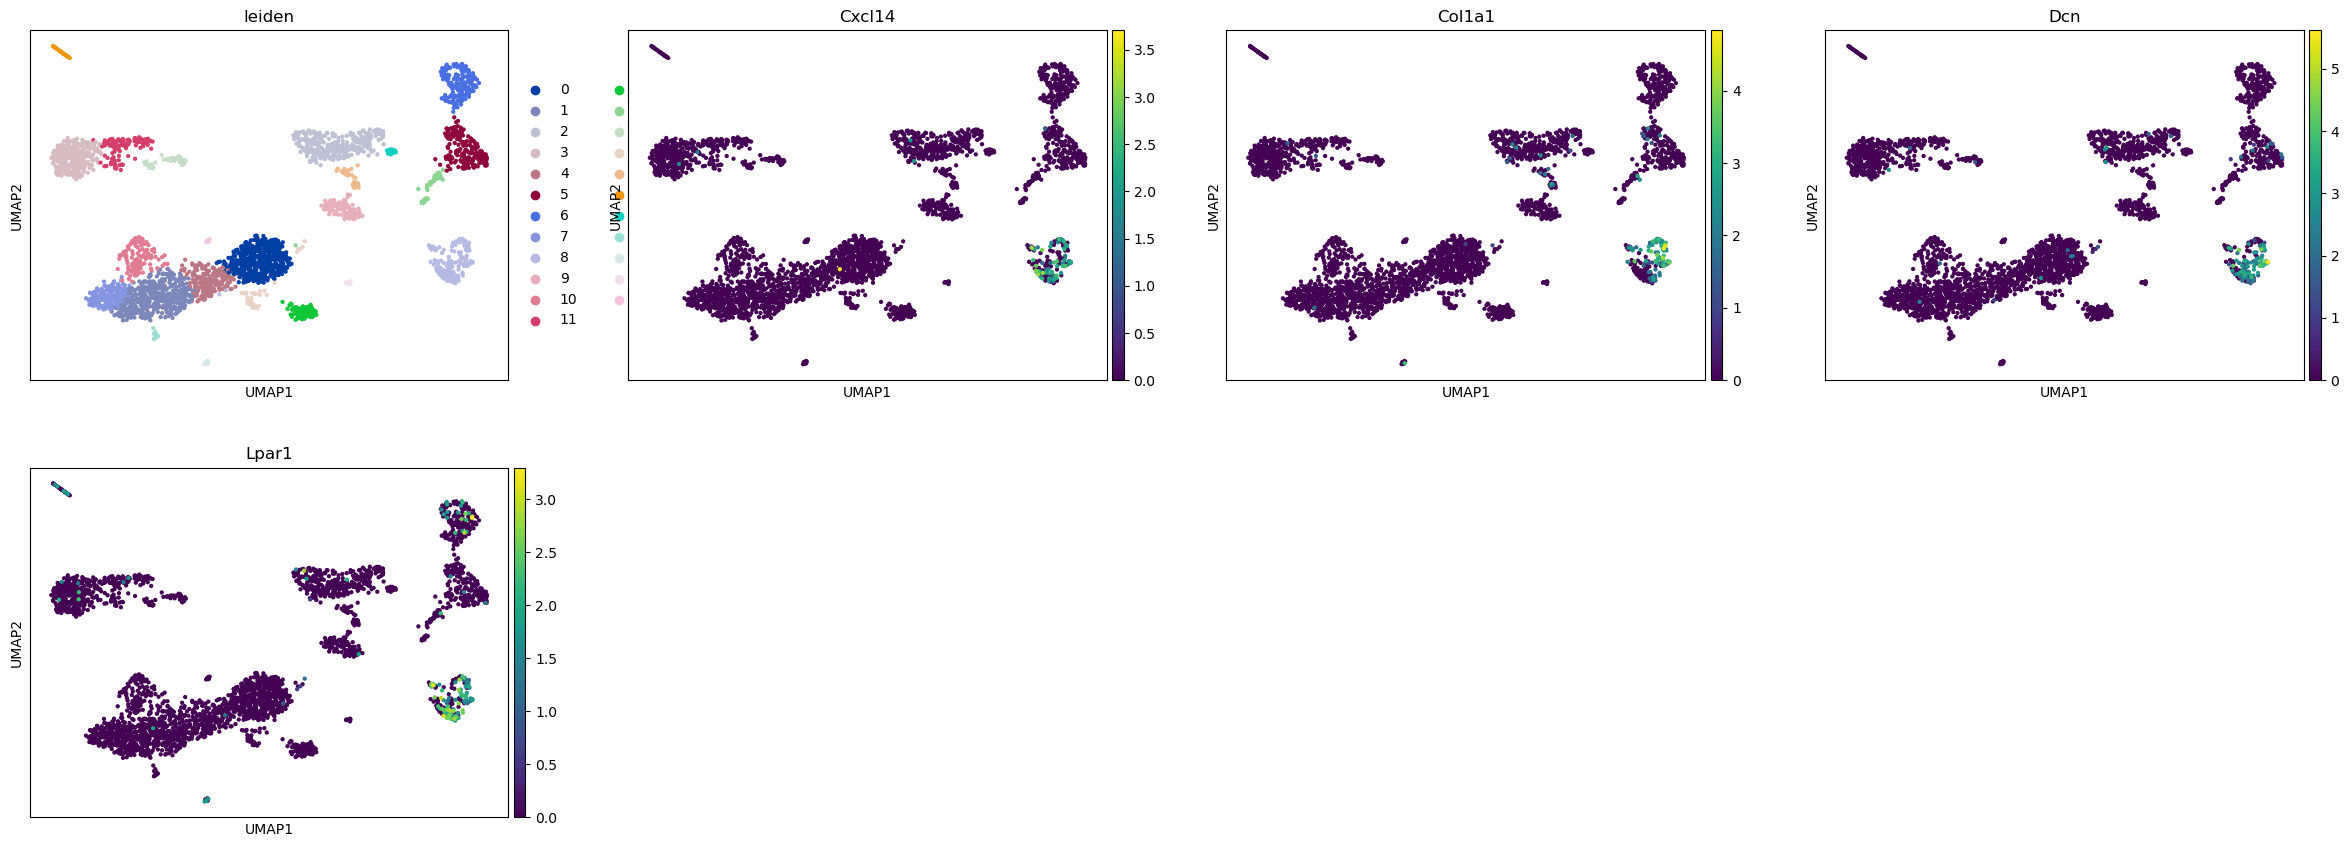

In [74]:
sc.pl.umap(adata, color=['leiden', 'Cxcl14', 'Col1a1', 'Dcn', 'Lpar1'])

In [75]:
adata.write(results_file)

## Conclusion

On all graphs, we can see Norn cells (a novel cell population that is responsible for EPO production in the kidney and is proposed by the authors of the paper). We can also see the marker genes that the authors highlighted as being highly selective for this population. Without metadata (the sample names and barcodes in the metadata did not match those used in the expression matrix), I am limited in how much further I can analyze the data.

The authors used a complex procedure to assign cell types to clusters, which also involved the expert opinion of researchers with expertise in kidney structure and physiology. This part is omitted here, as it was not the goal of this analysis.